<a href="https://colab.research.google.com/github/mamun-career-tech/Banking_Fraud_Detection_DeepLearning-MachineLearning/blob/main/V1_Banking_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required packages
!pip -q install imbalanced-learn joblib

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import tensorflow as tf
from tensorflow.keras import callbacks, layers, models, metrics

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [3]:
# Data loader
DATA_URLS = [
    "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv",
    "https://github.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/raw/refs/heads/master/creditcard.csv",
]

def load_fraud_data():
    last_error = None

    for url in DATA_URLS:
        try:
            print(f"Trying: {url}")
            df = pd.read_csv(url)
            print("Loaded from URL successfully.")
            return df
        except Exception as e:
            last_error = e
            print(f"Failed: {e}")

    print("\nAutomatic download failed.")
    print("Please upload 'creditcard.csv' manually from your computer.")

    try:
        from google.colab import files
        uploaded = files.upload()
        for fname in uploaded:
            if fname.lower().endswith(".csv"):
                df = pd.read_csv(fname)
                print(f"Loaded uploaded file: {fname}")
                return df
    except Exception as e:
        print("Manual upload step failed.")
        last_error = e

    raise RuntimeError(f"Could not load dataset. Last error: {last_error}")

df = load_fraud_data()
df.head()

Trying: https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv
Loaded from URL successfully.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Basic overview
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head())

fraud_rate = df["Class"].mean() * 100
print(f"\nFraud rate: {fraud_rate:.4f}%")
print(df["Class"].value_counts())

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing values:
Time    0
V1      0
V2      0
V3      0
V4      0
dtype: int64

Fraud rate: 0.1727%
Class
0    284315
1       492
Name: count, dtype: int64


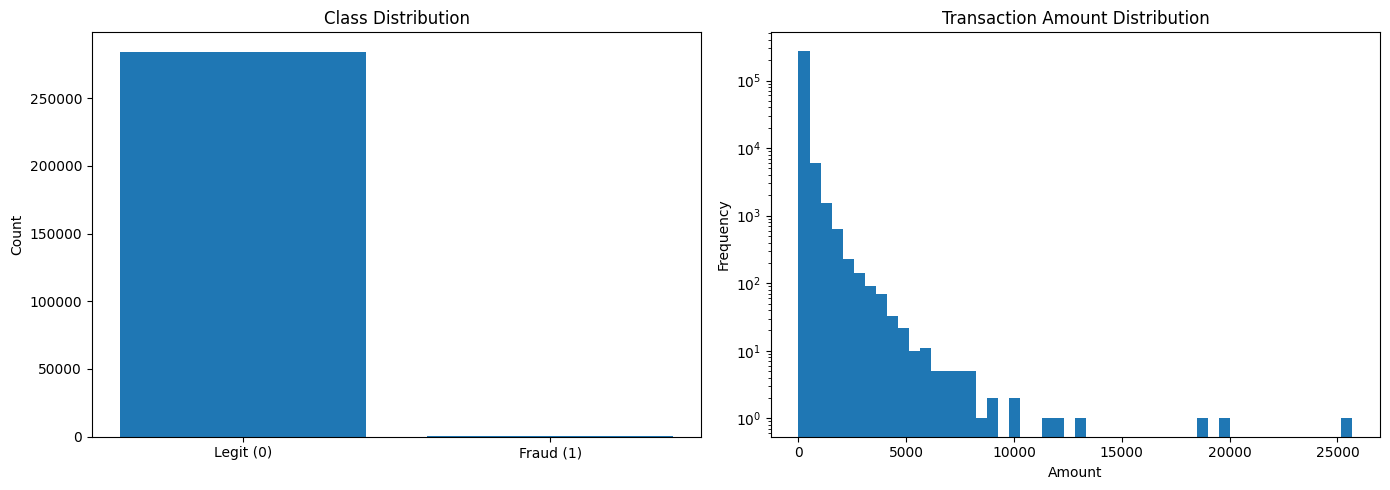

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [5]:
# Quick EDA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
class_counts = df["Class"].value_counts().sort_index()
axes[0].bar(["Legit (0)", "Fraud (1)"], class_counts.values)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")

# Transaction amount distribution
axes[1].hist(df["Amount"], bins=50)
axes[1].set_title("Transaction Amount Distribution")
axes[1].set_xlabel("Amount")
axes[1].set_ylabel("Frequency")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

print(df["Amount"].describe())

In [6]:
# Feature matrix and target
X = df.drop(columns=["Class"])
y = df["Class"]

# Train / validation / test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, stratify=y_train_full, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nFraud ratios")
print("Train:", y_train.mean())
print("Val  :", y_val.mean())
print("Test :", y_test.mean())

Train shape: (182276, 30)
Validation shape: (45569, 30)
Test shape: (56962, 30)

Fraud ratios
Train: 0.0017281485220215498
Val  : 0.0017336347078057452
Test : 0.0017204452090867595


In [7]:
# Preprocessing
numeric_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)

In [8]:
def find_best_threshold(y_true, y_prob, beta=2.0):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_threshold = 0.5
    best_score = -1

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        score = fbeta_score(y_true, y_pred, beta=beta, zero_division=0)
        if score > best_score:
            best_score = score
            best_threshold = t

    return best_threshold, best_score


def evaluate_predictions(y_true, y_prob, threshold=0.5, model_name="Model"):
    y_pred = (y_prob >= threshold).astype(int)

    scores = {
        "model": model_name,
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    }

    print(f"\n===== {model_name} =====")
    print(pd.Series(scores))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))

    return scores

# Machine Learning Models

In [9]:
# ML Model 1: Logistic Regression + SMOTE
log_reg_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE))
])

log_reg_pipeline.fit(X_train, y_train)

val_prob_lr = log_reg_pipeline.predict_proba(X_val)[:, 1]
best_t_lr, best_f2_lr = find_best_threshold(y_val, val_prob_lr, beta=2.0)

print("Best validation threshold (LR):", round(best_t_lr, 4))
print("Best validation F2 (LR):", round(best_f2_lr, 4))

Best validation threshold (LR): 0.99
Best validation F2 (LR): 0.6863


In [10]:
# Evaluate Logistic Regression on test set
test_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]
lr_scores = evaluate_predictions(
    y_test, test_prob_lr, threshold=best_t_lr, model_name="Logistic Regression + SMOTE"
)


===== Logistic Regression + SMOTE =====
model        Logistic Regression + SMOTE
threshold                           0.99
roc_auc                         0.974035
pr_auc                          0.718658
precision                       0.485714
recall                          0.867347
f1                              0.622711
f2                              0.749559
dtype: object

Confusion Matrix:
[[56774    90]
 [   13    85]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9984    0.9991     56864
           1     0.4857    0.8673    0.6227        98

    accuracy                         0.9982     56962
   macro avg     0.7427    0.9329    0.8109     56962
weighted avg     0.9989    0.9982    0.9984     56962



In [11]:
# ML Model 2: Random Forest
rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

rf_pipeline.fit(X_train, y_train)

val_prob_rf = rf_pipeline.predict_proba(X_val)[:, 1]
best_t_rf, best_f2_rf = find_best_threshold(y_val, val_prob_rf, beta=2.0)

print("Best validation threshold (RF):", round(best_t_rf, 4))
print("Best validation F2 (RF):", round(best_f2_rf, 4))

Best validation threshold (RF): 0.06
Best validation F2 (RF): 0.8105


In [12]:
# Evaluate Random Forest on test set
test_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
rf_scores = evaluate_predictions(
    y_test, test_prob_rf, threshold=best_t_rf, model_name="Random Forest"
)


===== Random Forest =====
model        Random Forest
threshold             0.06
roc_auc           0.957007
pr_auc            0.858236
precision         0.692913
recall            0.897959
f1                0.782222
f2                0.847784
dtype: object

Confusion Matrix:
[[56825    39]
 [   10    88]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9993    0.9996     56864
           1     0.6929    0.8980    0.7822        98

    accuracy                         0.9991     56962
   macro avg     0.8464    0.9486    0.8909     56962
weighted avg     0.9993    0.9991    0.9992     56962



In [13]:
# Compare ML model scores
ml_results = pd.DataFrame([lr_scores, rf_scores]).sort_values(
    by=["pr_auc", "recall", "f2"], ascending=False
)
ml_results

,model,threshold,roc_auc,pr_auc,precision,recall,f1,f2
1,Random Forest,0.06,0.957007,0.858236,0.692913,0.897959,0.782222,0.847784
0,Logistic Regression + SMOTE,0.99,0.974035,0.718658,0.485714,0.867347,0.622711,0.749559


# Deep Learning Model

In [14]:
# Prepare scaled arrays for deep learning
dl_scaler = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train_dl = dl_scaler.fit_transform(X_train)
X_val_dl = dl_scaler.transform(X_val)
X_test_dl = dl_scaler.transform(X_test)

classes = np.array([0, 1])
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = {
    0: float(class_weights_values[0]),
    1: float(class_weights_values[1]),
}

print("Class weights:", class_weight_dict)
print("DL train shape:", X_train_dl.shape)

Class weights: {0: 0.5008655700946906, 1: 289.32698412698414}
DL train shape: (182276, 30)


In [15]:
# Build neural network
def build_dl_model(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.30),

        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        layers.Dense(32, activation="relu"),
        layers.Dropout(0.20),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            metrics.AUC(name="roc_auc"),
            metrics.AUC(name="pr_auc", curve="PR"),
            metrics.Precision(name="precision"),
            metrics.Recall(name="recall")
        ]
    )
    return model

dl_model = build_dl_model(X_train_dl.shape[1])
dl_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,105 (59.00 KB)

 Trainable params: 14,721 (57.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [16]:
# Train neural network
early_stop = callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_pr_auc",
    mode="max",
    factor=0.5,
    patience=2,
    verbose=1
)

history = dl_model.fit(
    X_train_dl,
    y_train,
    validation_data=(X_val_dl, y_val),
    epochs=30,
    batch_size=2048,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.3856 - pr_auc: 0.2054 - precision: 0.0055 - recall: 0.9079 - roc_auc: 0.9310 - val_loss: 0.3151 - val_pr_auc: 0.6552 - val_precision: 0.0606 - val_recall: 0.8734 - val_roc_auc: 0.9545 - learning_rate: 0.0010
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2094 - pr_auc: 0.3866 - precision: 0.0201 - recall: 0.9143 - roc_auc: 0.9731 - val_loss: 0.1537 - val_pr_auc: 0.6997 - val_precision: 0.0757 - val_recall: 0.8481 - val_roc_auc: 0.9564 - learning_rate: 0.0010
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1630 - pr_auc: 0.5100 - precision: 0.0309 - recall: 0.9333 - roc_auc: 0.9827 - val_loss: 0.1020 - val_pr_auc: 0.6857 - val_precision: 0.0726 - val_recall: 0.8481 - val_roc_auc: 0.9491 - learning_rate: 0.0010
Epoch 4/30
87/90 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1569 - pr_auc: 0.4647 - precision: 0.0356 - recall: 0.9186 - roc_auc: 0.9844
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.

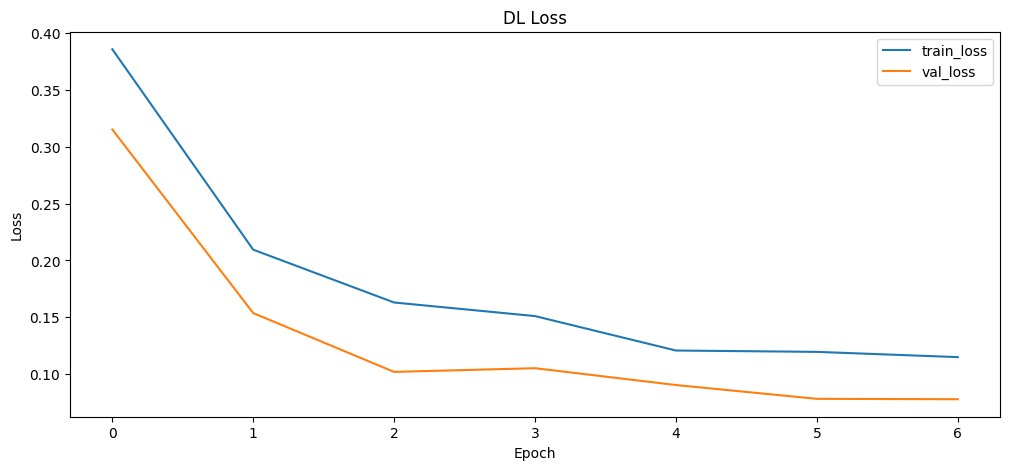

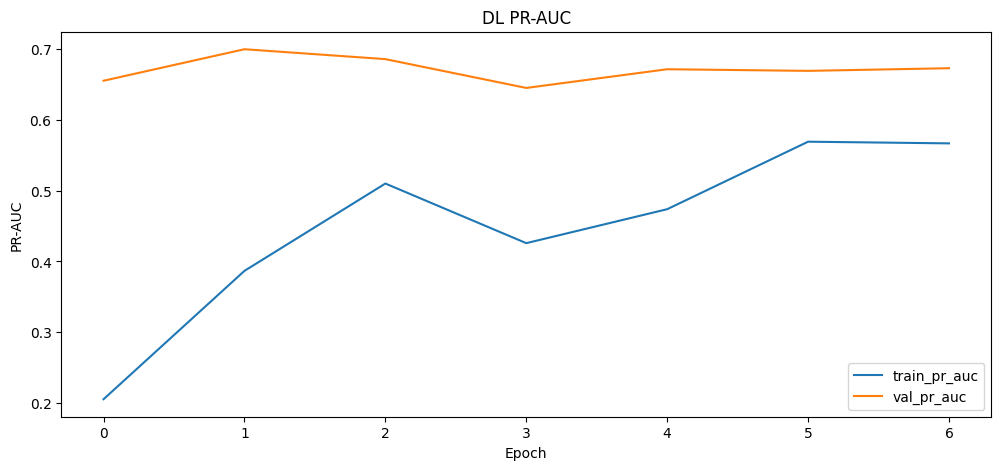

In [17]:
# Plot learning curves
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 5))
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("DL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(history_df["pr_auc"], label="train_pr_auc")
plt.plot(history_df["val_pr_auc"], label="val_pr_auc")
plt.title("DL PR-AUC")
plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.legend()
plt.show()

In [18]:
# Tune threshold using validation predictions
val_prob_dl = dl_model.predict(X_val_dl, verbose=0).ravel()
best_t_dl, best_f2_dl = find_best_threshold(y_val, val_prob_dl, beta=2.0)

print("Best validation threshold (DL):", round(best_t_dl, 4))
print("Best validation F2 (DL):", round(best_f2_dl, 4))

Best validation threshold (DL): 0.92
Best validation F2 (DL): 0.802


In [19]:
# Evaluate DL model on test set
test_prob_dl = dl_model.predict(X_test_dl, verbose=0).ravel()
dl_scores = evaluate_predictions(
    y_test, test_prob_dl, threshold=best_t_dl, model_name="Deep Neural Network"
)


===== Deep Neural Network =====
model        Deep Neural Network
threshold                   0.92
roc_auc                 0.968247
pr_auc                  0.692428
precision               0.674797
recall                  0.846939
f1                      0.751131
f2                      0.805825
dtype: object

Confusion Matrix:
[[56824    40]
 [   15    83]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9993    0.9995     56864
           1     0.6748    0.8469    0.7511        98

    accuracy                         0.9990     56962
   macro avg     0.8373    0.9231    0.8753     56962
weighted avg     0.9992    0.9990    0.9991     56962



In [20]:
# Compare all models
all_results = pd.DataFrame([lr_scores, rf_scores, dl_scores]).sort_values(
    by=["pr_auc", "recall", "f2"], ascending=False
).reset_index(drop=True)

all_results

,model,threshold,roc_auc,pr_auc,precision,recall,f1,f2
0,Random Forest,0.06,0.957007,0.858236,0.692913,0.897959,0.782222,0.847784
1,Logistic Regression + SMOTE,0.99,0.974035,0.718658,0.485714,0.867347,0.622711,0.749559
2,Deep Neural Network,0.92,0.968247,0.692428,0.674797,0.846939,0.751131,0.805825


In [21]:
# Pick best model by PR-AUC, then F2
best_model_name = all_results.iloc[0]["model"]
print("Best model selected:", best_model_name)

if best_model_name == "Logistic Regression + SMOTE":
    best_model_object = log_reg_pipeline
elif best_model_name == "Random Forest":
    best_model_object = rf_pipeline
else:
    best_model_object = dl_model

Best model selected: Random Forest


In [22]:
# Save trained models
os.makedirs("artifacts", exist_ok=True)

joblib.dump(log_reg_pipeline, "artifacts/logistic_regression_smote.joblib")
joblib.dump(rf_pipeline, "artifacts/random_forest.joblib")
joblib.dump(dl_scaler, "artifacts/dl_scaler.joblib")
dl_model.save("artifacts/deep_fraud_model.keras")

thresholds = {
    "logistic_regression_smote_threshold": float(best_t_lr),
    "random_forest_threshold": float(best_t_rf),
    "deep_learning_threshold": float(best_t_dl)
}
joblib.dump(thresholds, "artifacts/thresholds.joblib")

print("Saved files:")
for fname in sorted(os.listdir("artifacts")):
    print("-", fname)

Saved files:
- deep_fraud_model.keras
- dl_scaler.joblib
- logistic_regression_smote.joblib
- random_forest.joblib
- thresholds.joblib


In [23]:
# Example inference helper for a single transaction
feature_order = X.columns.tolist()

def predict_single_transaction(transaction_dict, model_type="rf"):
    sample = pd.DataFrame([transaction_dict])[feature_order]

    thresholds = joblib.load("artifacts/thresholds.joblib")

    if model_type == "lr":
        model = joblib.load("artifacts/logistic_regression_smote.joblib")
        prob = model.predict_proba(sample)[:, 1][0]
        threshold = thresholds["logistic_regression_smote_threshold"]

    elif model_type == "rf":
        model = joblib.load("artifacts/random_forest.joblib")
        prob = model.predict_proba(sample)[:, 1][0]
        threshold = thresholds["random_forest_threshold"]

    elif model_type == "dl":
        scaler = joblib.load("artifacts/dl_scaler.joblib")
        model = tf.keras.models.load_model("artifacts/deep_fraud_model.keras")
        prob = model.predict(scaler.transform(sample), verbose=0).ravel()[0]
        threshold = thresholds["deep_learning_threshold"]
    else:
        raise ValueError("model_type must be one of: 'lr', 'rf', 'dl'")

    pred = int(prob >= threshold)

    return {
        "probability_of_fraud": float(prob),
        "threshold_used": float(threshold),
        "predicted_class": pred,
        "label": "Fraud" if pred == 1 else "Legit"
    }

# Demo using one real row from the test set
demo_transaction = X_test.iloc[0].to_dict()
predict_single_transaction(demo_transaction, model_type="rf")

{'probability_of_fraud': 0.0,
 'threshold_used': 0.060000000000000005,
 'predicted_class': 0,
 'label': 'Legit'}